In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [417]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [418]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [419]:
df.shape

(7043, 21)

In [420]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [421]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [422]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [423]:
df.duplicated().sum()

np.int64(0)

In [424]:
df["customerID"].nunique()

7043

In [425]:
df.shape[0]

7043

In [426]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [427]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [428]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [429]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [430]:
# TotalCharges is the only column that should be numeric but was stored as text,
# because some rows contain blank values. Convert it to numeric and turn invalid blanks into NaN

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"     #If a value cannot be converted properly into a numeric value,don’t throw an error — turn that value into NaN
)

In [431]:
df["TotalCharges"].dtype

dtype('float64')

In [432]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [433]:
df = df.dropna(subset=["TotalCharges"])

In [434]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [435]:
df.shape

(7032, 21)

In [436]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [437]:
df["Churn"].value_counts(normalize=True) *100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [438]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [439]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [440]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [441]:
df_clean = df.copy()

In [442]:
df_clean = df_clean.drop("customerID",axis=1)

In [443]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [444]:
df_clean["Churn"] = df_clean["Churn"].map({
    "No":0,
    "Yes":1
})

In [445]:
df_clean["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

We separate the input features from the target variable.

- X = customer information used for prediction
- y = Churn, the value we want to predict

In [446]:
X = df_clean.drop("Churn",axis=1)
y = df_clean["Churn"]

In [447]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [448]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [449]:
X.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [450]:
categorical_columns = X.select_dtypes(
    include=["object","string"]
).columns

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

In [451]:
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [452]:
numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

## 7. Train-Test Split

In [453]:
X_train , X_test , y_train , y_test = train_test_split(
    X ,y ,test_size=0.2 ,random_state=42, stratify=y  #random_state=42 -> Use the same random split every time, so when you rerun the notebook later, the same rows go into training and testing
)                                                     # stratify=y keeps the same churn/non-churn class proportion in both the training and testing sets

In [454]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


## 8. Preprocessing

In [455]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),       #puts numerical features on a comparable scale
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)        #converts categorical features into numerical form that the model can use
    ]
)

In [456]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

## 9. Train Logistic Regression Model

In [457]:
model.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

## 10. Make Predictions

In [458]:
y_pred = model.predict(X_test)

In [459]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [460]:
print("Predicted:", y_pred[:10])
print("Actual:   ", y_test.iloc[:10].values)

Predicted: [0 1 0 0 0 0 0 0 1 0]
Actual:    [0 0 0 1 0 1 0 0 1 0]


## 11. Model Evaluation

In [461]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8038379530916845
Precision: 0.6484848484848484
Recall: 0.5721925133689839
F1 Score: 0.6079545454545454


In [462]:
print(confusion_matrix(y_test, y_pred))

[[917 116]
 [160 214]]


### Logistic Regression Results

The Logistic Regression model achieved approximately:

- Accuracy: 80.4%
- Precision: 64.8%
- Recall: 57.2%
- F1-score: 60.8%

The model correctly identified 214 churn customers but missed 160
customers who actually churned.

Although the overall accuracy is relatively high, the recall for the
churn class shows that the model still misses a considerable number
of actual churners.

In [463]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 12. Confusion Matrix Visualization

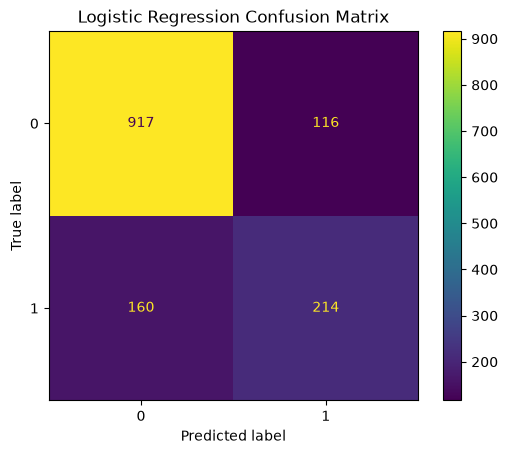

In [464]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 13. ROC-AUC Evaluation

In [465]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [466]:
y_prob = model.predict_proba(X_test)[:, 1]

In [467]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8359290473207676


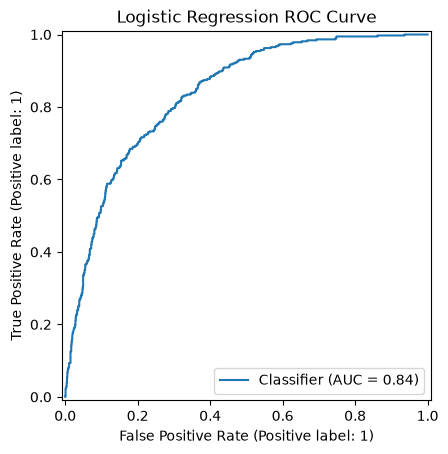

In [468]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("Logistic Regression ROC Curve")
plt.show()

ROC-AUC: 0.8359290473207676


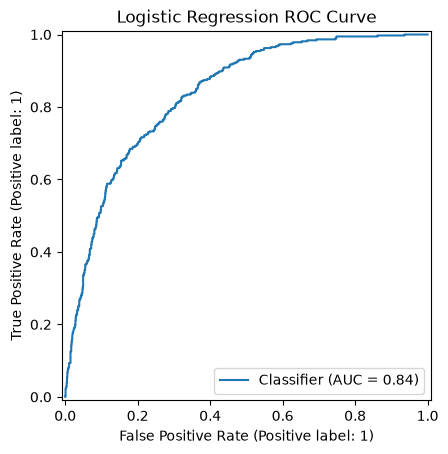

In [469]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("Logistic Regression ROC Curve")
plt.show()

## 14. Decision Tree Classifier

In [470]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [471]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [472]:
tree_pred = tree_model.predict(X_test)

In [473]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

Accuracy: 0.7356076759061834
Precision: 0.5026315789473684
Recall: 0.5106951871657754
F1 Score: 0.506631299734748


In [474]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



In [475]:
tree_prob = tree_model.predict_proba(X_test)[:, 1]

tree_auc = roc_auc_score(y_test, tree_prob)

print("ROC-AUC:", tree_auc)

ROC-AUC: 0.6633927970554586


### Decision Tree Results

The Decision Tree performed worse than Logistic Regression on the test data.

- Accuracy: 73.6%
- Precision: 50.3%
- Recall: 51.1%
- F1-score: 50.7%
- ROC-AUC: 66.3%

The default Decision Tree may be too complex and may not generalize well
to unseen data.

In [476]:
print("Training Accuracy:", tree_model.score(X_train, y_train))
print("Testing Accuracy:", tree_model.score(X_test, y_test))

Training Accuracy: 0.9987555555555555
Testing Accuracy: 0.7356076759061834


In [477]:
tree = tree_model.named_steps["classifier"]

print("Tree Depth:", tree.get_depth())
print("Number of Leaves:", tree.get_n_leaves())

Tree Depth: 24
Number of Leaves: 1109


### Overfitting Check

The Decision Tree achieved approximately 99.9% training accuracy but only
73.6% testing accuracy.

This large gap indicates overfitting.

The tree also reached a depth of 24 with 1109 leaf nodes, showing that the
model became very complex and learned the training data too closely.

## 15. Random Forest Classifier

In [478]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,    #Build 100 decision trees
            random_state=42
        ))
    ]
)

In [479]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [480]:
rf_pred = rf_model.predict(X_test)

In [481]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.783226723525231
Precision: 0.6193771626297578
Recall: 0.4786096256684492
F1 Score: 0.5399698340874811


In [482]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC:", rf_auc)

ROC-AUC: 0.8133273110353004


In [483]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy:", rf_model.score(X_test, y_test))

Training Accuracy: 0.9987555555555555
Testing Accuracy: 0.783226723525231


### Random Forest Results

The Random Forest performed better than the single Decision Tree,
but Logistic Regression still achieved better overall results.

- Accuracy: 78.3%
- Precision: 61.9%
- Recall: 47.9%
- F1-score: 54.0%
- ROC-AUC: 81.3%

The large difference between training accuracy (99.9%) and testing
accuracy (78.3%) indicates that the default Random Forest is also overfitting.

## 16. Gradient Boosting Classifier

In [484]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [485]:
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [486]:
gb_pred = gb_model.predict(X_test)

In [487]:
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))

Accuracy: 0.7967306325515281
Precision: 0.6428571428571429
Recall: 0.5294117647058824
F1 Score: 0.5806451612903226


In [488]:
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_auc = roc_auc_score(y_test, gb_prob)

print("ROC-AUC:", gb_auc)

ROC-AUC: 0.8386895548503657


In [489]:
print("Training Accuracy:", gb_model.score(X_train, y_train))
print("Testing Accuracy:", gb_model.score(X_test, y_test))

Training Accuracy: 0.8302222222222222
Testing Accuracy: 0.7967306325515281


### Gradient Boosting Results

Gradient Boosting achieved:

- Accuracy: 79.7%
- Precision: 64.3%
- Recall: 52.9%
- F1-score: 58.1%
- ROC-AUC: 83.9%

The training accuracy (83.0%) and testing accuracy (79.7%) are relatively
close, suggesting that the model generalizes better than the Decision Tree
and Random Forest.

Gradient Boosting also achieved the highest ROC-AUC score so far.

## 17. Model Comparison

In [490]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC_AUC": [
        roc_auc,
        tree_auc,
        rf_auc,
        gb_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
1,Decision Tree,0.735608,0.502632,0.510695,0.506631,0.663393
2,Random Forest,0.783227,0.619377,0.478610,0.539970,0.813327
3,Gradient Boosting,0.796731,0.642857,0.529412,0.580645,0.838690


## 18. Cross-Validation

In [491]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [492]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [493]:
logistic_cv = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

gb_cv = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

In [494]:
print("Logistic Regression CV AUC:", logistic_cv)
print("Logistic Mean AUC:", logistic_cv.mean())

print()

print("Gradient Boosting CV AUC:", gb_cv)
print("Gradient Boosting Mean AUC:", gb_cv.mean())

Logistic Regression CV AUC: [0.84631581 0.8440929  0.83771774 0.84884846 0.85332059]
Logistic Mean AUC: 0.8460590993383919

Gradient Boosting CV AUC: [0.84264336 0.84432167 0.84752039 0.85060776 0.85087297]
Gradient Boosting Mean AUC: 0.8471932268173978


### Cross-Validation Results

Using 5-fold stratified cross-validation:

- Logistic Regression mean ROC-AUC: 0.846
- Gradient Boosting mean ROC-AUC: 0.847

Both models show consistent performance across the folds.
Gradient Boosting achieved a slightly higher mean ROC-AUC, but the
difference between the two models is very small.

## 19. Hyperparameter Tuning - Gradient Boosting

In [495]:
from sklearn.model_selection import GridSearchCV

gb_param_grid = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gb_model,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [496]:
gb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [2, 3], 'classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [497]:
print("Best Parameters:", gb_grid.best_params_)
print("Best CV ROC-AUC:", gb_grid.best_score_)

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.8498963453642894


### Gradient Boosting Tuning Results

GridSearchCV found the best Gradient Boosting parameters:

- Learning rate: 0.1
- Maximum tree depth: 2
- Number of estimators: 100

The best cross-validation ROC-AUC was approximately 0.849.

This slightly improved the model compared with the default Gradient
Boosting configuration.

## 20. Hyperparameter Tuning - Logistic Regression

In [498]:
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}

In [499]:
logistic_grid = GridSearchCV(
    model,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [500]:
logistic_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [501]:
print("Best Parameters:", logistic_grid.best_params_)
print("Best CV ROC-AUC:", logistic_grid.best_score_)

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best CV ROC-AUC: 0.8462720772227037


## 21. Final Evaluation of Tuned Models

In [502]:
best_logistic = logistic_grid.best_estimator_
best_gb = gb_grid.best_estimator_

In [503]:
log_pred_final = best_logistic.predict(X_test)
log_prob_final = best_logistic.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred_final))
print("Precision:", precision_score(y_test, log_pred_final))
print("Recall:", recall_score(y_test, log_pred_final))
print("F1 Score:", f1_score(y_test, log_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, log_prob_final))

Tuned Logistic Regression
Accuracy: 0.8002842928216063
Precision: 0.6396396396396397
Recall: 0.56951871657754
F1 Score: 0.6025459688826026
ROC-AUC: 0.8350878237416589


In [504]:
gb_pred_final = best_gb.predict(X_test)
gb_prob_final = best_gb.predict_proba(X_test)[:, 1]

print("Tuned Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, gb_pred_final))
print("Precision:", precision_score(y_test, gb_pred_final))
print("Recall:", recall_score(y_test, gb_pred_final))
print("F1 Score:", f1_score(y_test, gb_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob_final))

Tuned Gradient Boosting
Accuracy: 0.7924662402274343
Precision: 0.6385135135135135
Recall: 0.5053475935828877
F1 Score: 0.564179104477612
ROC-AUC: 0.8392835881162287


## 22. Final Model Selection

After hyperparameter tuning, Logistic Regression and Gradient Boosting
showed similar performance.

Tuned Logistic Regression:
- Accuracy: 80.0%
- Precision: 64.0%
- Recall: 57.0%
- F1-score: 60.3%
- ROC-AUC: 83.5%

Tuned Gradient Boosting:
- Accuracy: 79.2%
- Precision: 63.9%
- Recall: 50.5%
- F1-score: 56.4%
- ROC-AUC: 83.9%

Although Gradient Boosting achieved a slightly higher ROC-AUC,
Logistic Regression achieved better recall, F1-score, and overall accuracy.

Therefore, Logistic Regression was selected as the final model.

## 23. Feature Importance / Model Interpretation

In [505]:
final_model = best_logistic

In [506]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = final_model.named_steps["classifier"].coef_[0]

In [507]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,1.198044
3,num__TotalCharges,0.681263
36,cat__Contract_Month-to-month,0.581115
32,cat__StreamingTV_Yes,0.479177
35,cat__StreamingMovies_Yes,0.466184
14,cat__MultipleLines_Yes,0.296604
26,cat__DeviceProtection_Yes,0.217945
43,cat__PaymentMethod_Electronic check,0.150966
18,cat__OnlineSecurity_No,0.136532
27,cat__TechSupport_No,0.113799


### Features Associated with Lower Churn Prediction

Negative Logistic Regression coefficients indicate features that push
the model toward predicting that a customer will not churn.

In [508]:
feature_importance.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
2,num__MonthlyCharges,-1.822650
1,num__tenure,-1.388844
15,cat__InternetService_DSL,-1.069417
38,cat__Contract_Two year,-0.827744
34,cat__StreamingMovies_No internet service,-0.555060
22,cat__OnlineBackup_No internet service,-0.555060
25,cat__DeviceProtection_No internet service,-0.555060
28,cat__TechSupport_No internet service,-0.555060
31,cat__StreamingTV_No internet service,-0.555060
17,cat__InternetService_No,-0.555060


## 24. Save Final Model

In [509]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

## 25. Test Prediction on a New Customer

In [510]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.50],
    "TotalCharges": [1026.00]
})

In [511]:
prediction = final_model.predict(new_customer)

probability = final_model.predict_proba(new_customer)[:, 1]

In [512]:
print("Prediction:", prediction[0])
print("Churn Probability:", probability[0])


Prediction: 1
Churn Probability: 0.780880473949668


In [513]:
if prediction[0] == 1:
    print("Customer is predicted to CHURN")
else:
    print("Customer is predicted to NOT CHURN")

print(f"Churn Probability: {probability[0] * 100:.2f}%")

Customer is predicted to CHURN
Churn Probability: 78.09%


## 22. Final Model Selection

After hyperparameter tuning, Logistic Regression and Gradient Boosting
showed similar performance.

Tuned Logistic Regression:
- Accuracy: 80.0%
- Precision: 64.0%
- Recall: 57.0%
- F1-score: 60.3%
- ROC-AUC: 83.5%

Tuned Gradient Boosting:
- Accuracy: 79.2%
- Precision: 63.9%
- Recall: 50.5%
- F1-score: 56.4%
- ROC-AUC: 83.9%

Although Gradient Boosting achieved a slightly higher ROC-AUC,
Logistic Regression achieved better recall, F1-score, and overall accuracy.

Therefore, Logistic Regression was selected as the final model.